# CineMatch — Data Exploration
## Movie Recommendation System

This notebook explores the MovieLens dataset to understand the data 
before building our recommendation model.

### Datasets Used:
- **MovieLens Small** — 100,836 ratings by 610 users across 9,724 movies
- **TMDB** — movie metadata and posters (used in the app)

## 1. Loading the Data
We load three CSV files from the MovieLens dataset:
- `movies.csv` — movie titles and genres
- `ratings.csv` — user ratings (our core ML data)
- `links.csv` — bridges MovieLens IDs to TMDB IDs for poster fetching

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Absolute path - works regardless of where notebook is located
base_dir = r"C:\Users\USER\Desktop\movie recommender\movie-recommender"

# Load our datasets
movies = pd.read_csv(os.path.join(base_dir, 'data', 'ml-latest-small', 'movies.csv'))
ratings = pd.read_csv(os.path.join(base_dir, 'data', 'ml-latest-small', 'ratings.csv'))
links = pd.read_csv(os.path.join(base_dir, 'data', 'ml-latest-small', 'links.csv'))

print(" Datasets loaded successfully!")
print(f"Movies: {movies.shape}")
print(f"Ratings: {ratings.shape}")
print(f"Links: {links.shape}")

 Datasets loaded successfully!
Movies: (9742, 3)
Ratings: (100836, 4)
Links: (9742, 3)


## 2. Understanding the Data Structure
Let's peek at the first few rows of each dataset to understand 
what we're working with.

In [7]:
print("=== MOVIES ===")
print(movies.head())

print("\n=== RATINGS ===")
print(ratings.head())

print("\n=== LINKS ===")
print(links.head())

=== MOVIES ===
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

=== RATINGS ===
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

=== LINKS ===
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885

## 3. Ratings Analysis
Key questions:
- How many users and movies do we have?
- What is the rating scale?
- How active are users?

In [ ]:
print("=== RATINGS SUMMARY ===")
print(ratings.describe())

print(f"\nTotal unique users: {ratings['userId'].nunique()}")
print(f"Total unique movies rated: {ratings['movieId'].nunique()}")
print(f"Total ratings: {len(ratings)}")
print(f"\nRating scale: {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"Average rating: {ratings['rating'].mean():.2f}")

## 4. Visualizing Rating Patterns
Two key charts:
- **Rating distribution** — do users rate generously or harshly?
- **Ratings per user** — how active are users in our dataset?

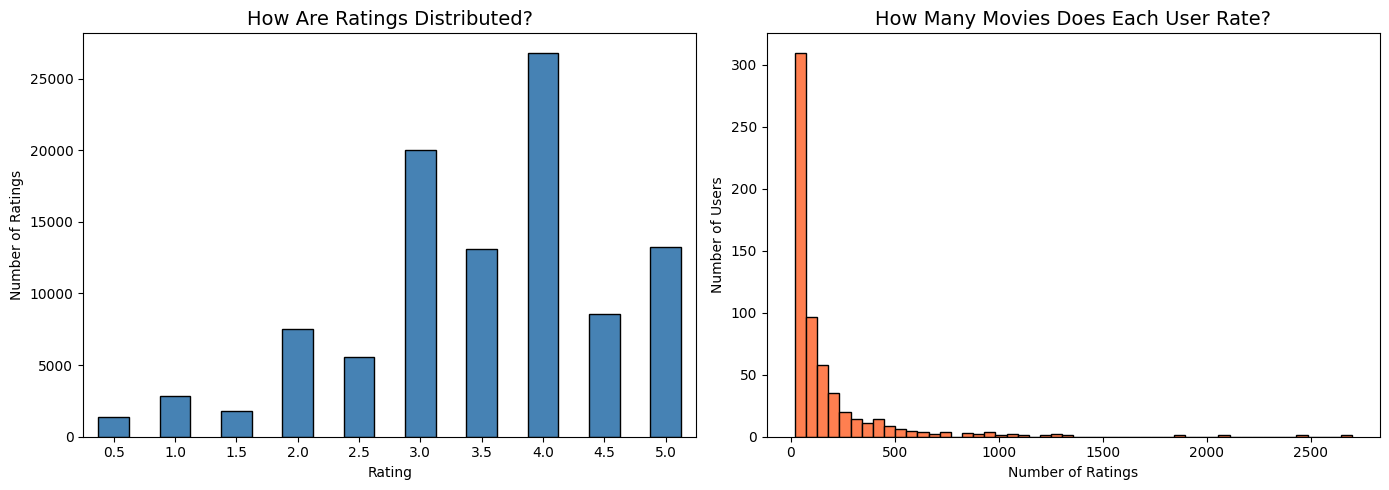


Most active user rated: 2698 movies
Least active user rated: 20 movies
Average user rates: 165 movies


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('How Are Ratings Distributed?', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Ratings')
axes[0].tick_params(axis='x', rotation=0)

ratings_per_user = ratings.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=50, color='coral', edgecolor='black')
axes[1].set_title('How Many Movies Does Each User Rate?', fontsize=14)
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

print(f"\nMost active user rated: {ratings_per_user.max()} movies")
print(f"Least active user rated: {ratings_per_user.min()} movies")
print(f"Average user rates: {ratings_per_user.mean():.0f} movies")

## 5. Genre Analysis
Understanding which genres dominate our dataset helps us 
validate our content-based fallback recommendations later.

In [10]:
print("=== MOVIES SUMMARY ===")
print(f"Total movies: {len(movies)}")

all_genres = movies['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts()
print("\n=== GENRE BREAKDOWN ===")
print(genre_counts)

=== MOVIES SUMMARY ===
Total movies: 9742

=== GENRE BREAKDOWN ===
genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64


## 6. Most Rated Movies
The most rated movies give us insight into dataset bias — 
heavily rated movies will have stronger collaborative signals.

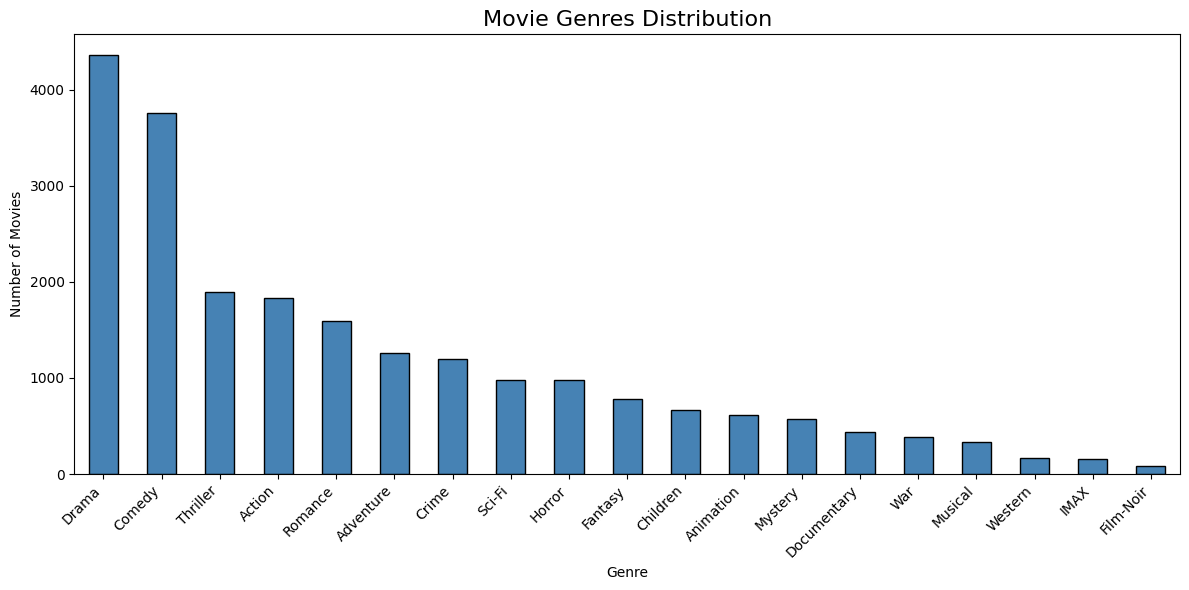

=== TOP 10 MOST RATED MOVIES ===
                                    title  rating_count
                      Forrest Gump (1994)           329
         Shawshank Redemption, The (1994)           317
                      Pulp Fiction (1994)           307
         Silence of the Lambs, The (1991)           279
                       Matrix, The (1999)           278
Star Wars: Episode IV - A New Hope (1977)           251
                     Jurassic Park (1993)           238
                        Braveheart (1995)           237
        Terminator 2: Judgment Day (1991)           224
                  Schindler's List (1993)           220


In [11]:
plt.figure(figsize=(12, 6))
genre_counts[genre_counts.index != '(no genres listed)'].plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Movie Genres Distribution', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("=== TOP 10 MOST RATED MOVIES ===")
movie_rating_counts = ratings.groupby('movieId').size().reset_index(name='rating_count')
movie_rating_counts = movie_rating_counts.merge(movies[['movieId', 'title']], on='movieId')
top_10 = movie_rating_counts.sort_values('rating_count', ascending=False).head(10)
print(top_10[['title', 'rating_count']].to_string(index=False))

## 7. Data Cleaning
We clean the data by:
1. Dropping the `timestamp` column — not needed for recommendations
2. Removing movies with no genre information
3. Merging ratings with movie titles for easier analysis

In [12]:
print("=== BEFORE CLEANING ===")
print(f"Ratings shape: {ratings.shape}")
print(f"Movies shape: {movies.shape}")

ratings_clean = ratings.drop(columns=['timestamp'])
print("\n Dropped timestamp column")

movies_clean = movies[movies['genres'] != '(no genres listed)'].copy()
print(f" Removed {len(movies) - len(movies_clean)} movies with no genres")

ratings_with_titles = ratings_clean.merge(movies_clean[['movieId', 'title', 'genres']], on='movieId')
print(f" Merged ratings with movie info")

print("\n=== AFTER CLEANING ===")
print(f"Ratings shape: {ratings_with_titles.shape}")
print(f"Movies shape: {movies_clean.shape}")
print(f"\nSample of clean data:")
print(ratings_with_titles.head())

=== BEFORE CLEANING ===
Ratings shape: (100836, 4)
Movies shape: (9742, 3)

 Dropped timestamp column
 Removed 34 movies with no genres
 Merged ratings with movie info

=== AFTER CLEANING ===
Ratings shape: (100789, 5)
Movies shape: (9708, 3)

Sample of clean data:
   userId  movieId  rating                        title  \
0       1        1     4.0             Toy Story (1995)   
1       1        3     4.0      Grumpier Old Men (1995)   
2       1        6     4.0                  Heat (1995)   
3       1       47     5.0  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


## 8. Building the User-Movie Matrix
The User-Movie Matrix is the foundation of our recommendation system.
- Rows = Users
- Columns = Movies  
- Values = Ratings (0 means not yet rated)

With 610 users and 9,724 movies, our matrix is **98.3% empty** — 
this is called a **sparse matrix** and predicting those empty cells 
is exactly what our model does!

In [13]:
user_movie_matrix = ratings_clean.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_movie_matrix_filled = user_movie_matrix.fillna(0)

print(f" Matrix built!")
print(f"Shape: {user_movie_matrix_filled.shape}")
print(f"Users: {user_movie_matrix_filled.shape[0]}")
print(f"Movies: {user_movie_matrix_filled.shape[1]}")

total_cells = user_movie_matrix.shape[0] * user_movie_matrix.shape[1]
filled_cells = user_movie_matrix.count().sum()
sparsity = (1 - filled_cells/total_cells) * 100
print(f"\nMatrix sparsity: {sparsity:.1f}% empty")

 Matrix built!
Shape: (610, 9724)
Users: 610
Movies: 9724

Matrix sparsity: 98.3% empty


## 9. Saving Clean Data
We save our cleaned data so we don't have to redo this every session.

In [14]:
ratings_clean.to_csv(os.path.join(base_dir, 'data', 'ratings_clean.csv'), index=False)
ratings_with_titles.to_csv(os.path.join(base_dir, 'data', 'ratings_with_titles.csv'), index=False)
movies_clean.to_csv(os.path.join(base_dir, 'data', 'movies_clean.csv'), index=False)

print(" Saved ratings_clean.csv")
print(" Saved ratings_with_titles.csv")
print(" Saved movies_clean.csv")

 Saved ratings_clean.csv
 Saved ratings_with_titles.csv
 Saved movies_clean.csv


## Summary
From our exploration we learned:
- 100,836 ratings across 610 users and 9,724 movies
- Average rating is 3.50 on a 0.5–5.0 scale
- Drama and Comedy are the most represented genres
- 98.3% of the user-movie matrix is empty (sparse)
- The model's job is to predict those empty cells!

Next: `02_model_building.ipynb` — building and evaluating the recommendation model.